In [7]:
import sys
from pathlib import Path
_root = Path.cwd().parent  # notebooks/ -> project root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root

Nombre de tours : 1.0
[SegmentEngine] Démarrage : 160 segments × 50 ms  |  overlap=10 ms  |  HRIR=512 smp  |  crossfade='cosine'
[SegmentEngine] Rendu terminé : 353311 échantillons (8.01s)


### LA4 — rotation 360° sens horaire (devant → droite → derrière → gauche)

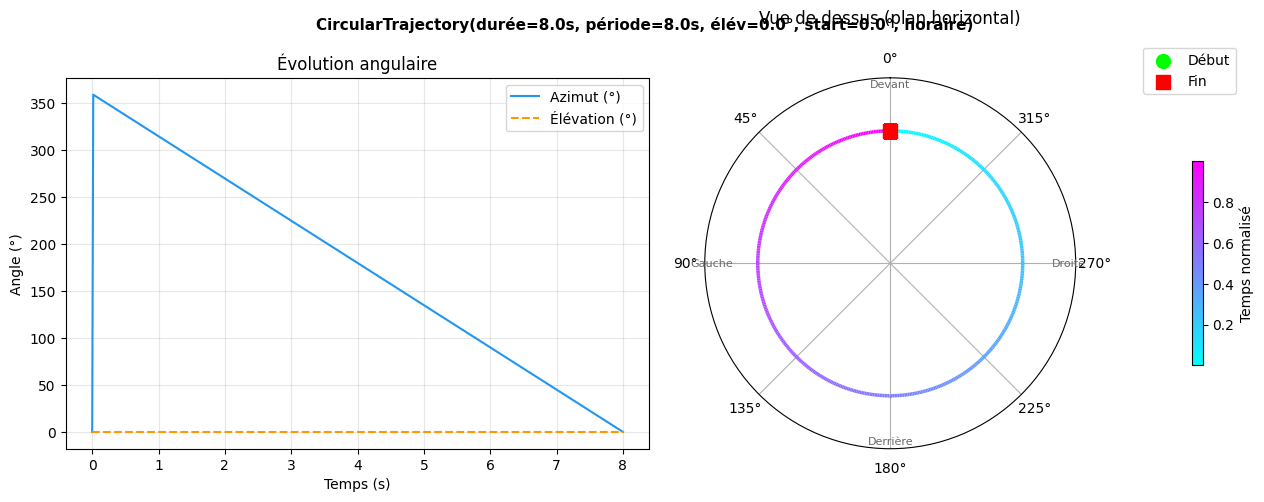

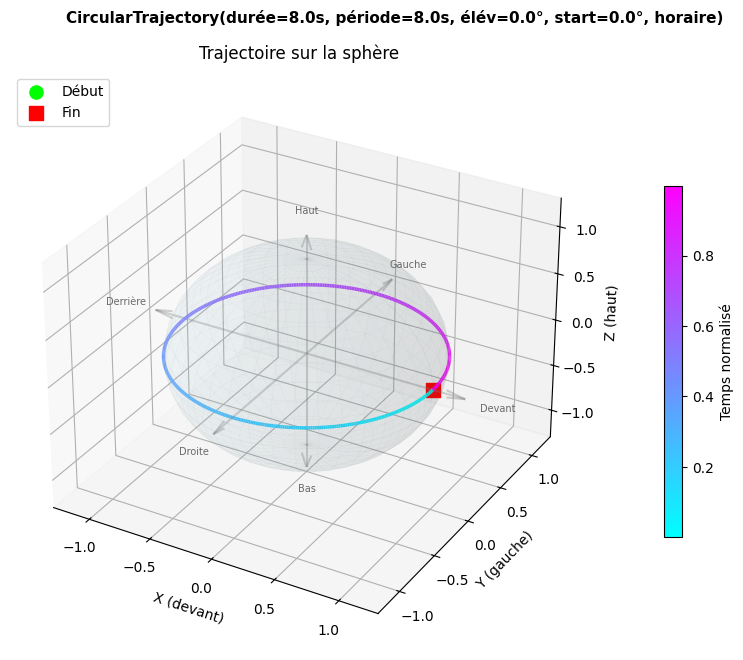

In [ ]:
import numpy as np
from IPython.display import Audio, display, Markdown
from hrtf import HRTF
from GenerateSound import BurstNote, Note
from Trajectory import CircularTrajectory
from DynamicConvolver import DynamicConvolver

# ── 1. HRTF ─────────────────────────────────────────────────────────────
hrtf = HRTF.from_sofa(ROOT / "dataset" / "IRC_1002_C_44100.sofa")

# ── 2. Signal : sinus LA4 (440 Hz) ──────────────────────────────────────
duration = 8           # secondes — durée = 1 tour complet
la_burst = BurstNote(
    note           = "LA",
    octave         = 4,
    burst_duration = 0.25,   # durée de chaque rafale
    repeat_every   = 1.0,    # 1 burst par seconde → 8 impacts sur le tour
    duration       = duration,
    sr             = 44_100,
    fade_ms        = 10.0,
)
signal = la_burst.generate()


# ── 3. Trajectoire : 1 tour complet en 8 s (sens horaire) ───────────────
#   Convention SOFA, vu de dessus :
#   devant (0°) → droite (270°) → derrière (180°) → gauche (90°) → devant
traj = CircularTrajectory(
    duration_s = duration,
    period_s   = duration,   # period == duration → exactement 360°
    elevation  = 0.0,        # plan horizontal
    start_az   = 0.0,        # part de devant
    clockwise  = True,
)
print(f"Nombre de tours : {traj.n_rotations():.1f}")

# ── 4. Convolution dynamique ─────────────────────────────────────────────
conv = DynamicConvolver(
    hrtf       = hrtf,
    signal     = signal,
    sr         = la_burst.sr,
    trajectory = traj,
    segment_ms = 50,
    overlap_ms = 10,
)
output = conv.run()   # shape (N, 2)

# ── 5. Écoute ────────────────────────────────────────────────────────────
display(Markdown("### LA4 — rotation 360° sens horaire (devant → droite → derrière → gauche)"))
display(Audio(output.T, rate=la_burst.sr, normalize=False))

# ── 6. Visualisation de la trajectoire ──────────────────────────────────
traj.plot_all()

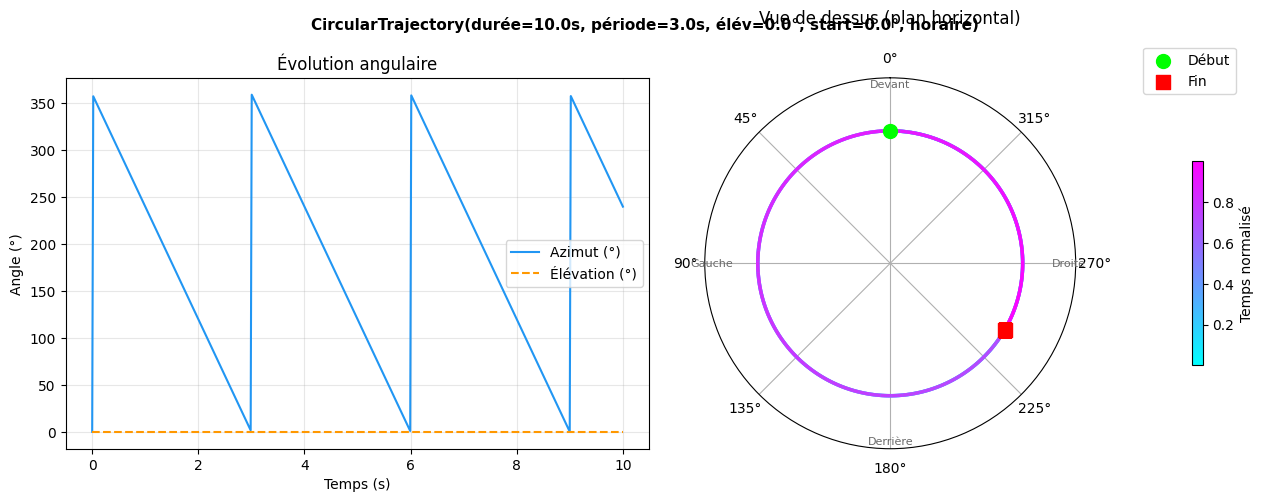

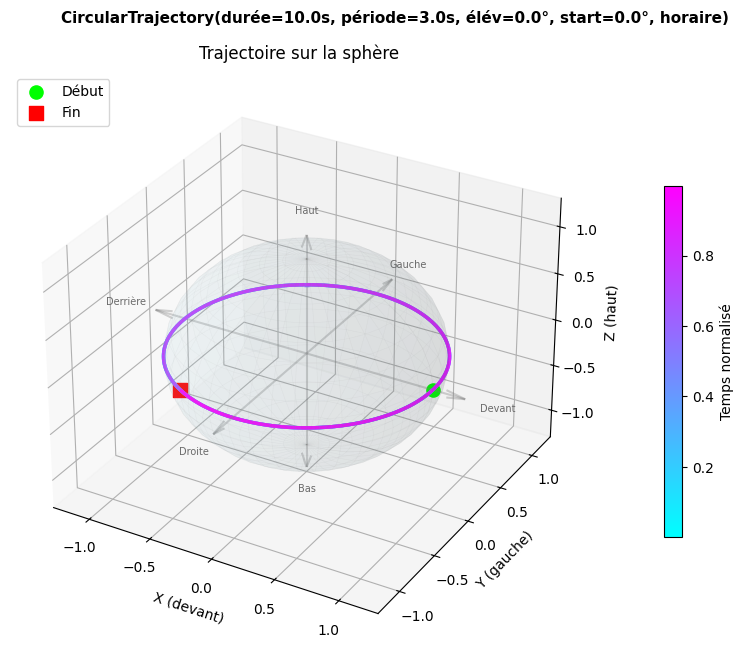

In [6]:
traj.plot_all()

In [ ]:
from Trajectory import RectilinearTrajectory

# Corde de az=60° (avant-droite) → az=300° (avant-gauche)
# Les deux extrémités sont à R=2.06 m ; la corde passe devant à r_min ≈ 1.03 m
traj_rect = RectilinearTrajectory(
    duration_s = 5.0,
    start_az   = 60.0,   # avant-droit (60°)
    start_el   = 0.0,
    end_az     = 300.0,  # avant-gauche (300° ≡ −60°)
    end_el     = 0.0,
    R          = 2.06,   # rayon de la sphère HRTF (IRCAM LISTEN)
)

print(f"Angle entre extrémités  : {traj_rect.theta_deg:.1f}°")
print(f"Distance aux extrémités : {traj_rect.R:.2f} m")
print(f"Distance minimale       : {traj_rect.r_min:.2f} m  (à t = {traj_rect._duration/2:.1f} s)")
print()
print(traj_rect)


ImportError: cannot import name 'RectilinearTrajectory' from 'Trajectory' (c:\son_spatialisation\Trajectory.py)